In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("superMarket Analysis.csv")

In [3]:
df.head()

,Invoice_Id,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
df.shape

(1000, 17)

In [5]:
df.columns

Index(['Invoice_Id', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice_Id               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [7]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [8]:
df.isnull().sum()

Invoice_Id                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Invoice_Id                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [11]:
df["Date"] = pd.to_datetime(df["Date"])

In [12]:
df["Month"] = df["Date"].dt.month_name()

In [13]:
df["Day"] = df["Date"].dt.day_name()

In [14]:
df["Hour"] = pd.to_datetime(df["Time"])

C:\Users\DELL\AppData\Local\Temp\ipykernel_9844\1364528128.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"])


In [15]:
df.groupby("City")["Sales"].sum().sort_values(ascending=False)

City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Sales, dtype: float64

In [16]:
df.groupby("Branch")["Sales"].sum().sort_values(ascending=False)

Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64

In [17]:
df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64

In [18]:
df.groupby("Gender")["Sales"].sum().sort_values(ascending=False)

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64

In [19]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)
print(city_sales)
product_sales = df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)
print(product_sales)

City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Sales, dtype: float64
Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


In [20]:
payment_method = df["Payment"].value_counts()
print(payment_method)

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


In [21]:
gender_sales = df.groupby("Gender")["Sales"].sum()
print(gender_sales)
gender_rating = df.groupby("Gender")["Rating"].mean()
print(gender_rating)

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64
Gender
Female    6.959720
Male      6.989977
Name: Rating, dtype: float64


In [22]:
monthly_sales = df.groupby("Month")["Sales"].sum()
print(monthly_sales)

Month
February     97219.374
January     116291.868
March       109455.507
Name: Sales, dtype: float64


In [23]:
hourly_sales = df.groupby("Hour")["Sales"].sum()
print(hourly_sales)

Hour
2026-07-10 10:00:00    979.9230
2026-07-10 10:01:00    205.9470
2026-07-10 10:02:00    784.6125
2026-07-10 10:03:00    335.0130
2026-07-10 10:04:00    827.0850
                         ...   
2026-07-10 20:52:00    352.5795
2026-07-10 20:54:00    375.6060
2026-07-10 20:55:00    783.3000
2026-07-10 20:57:00    148.9950
2026-07-10 20:59:00    408.1455
Name: Sales, Length: 506, dtype: float64


In [24]:
day_sales = df.groupby("Day")["Sales"].sum()
print(day_sales)

Day
Friday       43926.3405
Monday       37899.0780
Saturday     56120.8095
Sunday       44457.8925
Thursday     45349.2480
Tuesday      51482.2455
Wednesday    43731.1350
Name: Sales, dtype: float64


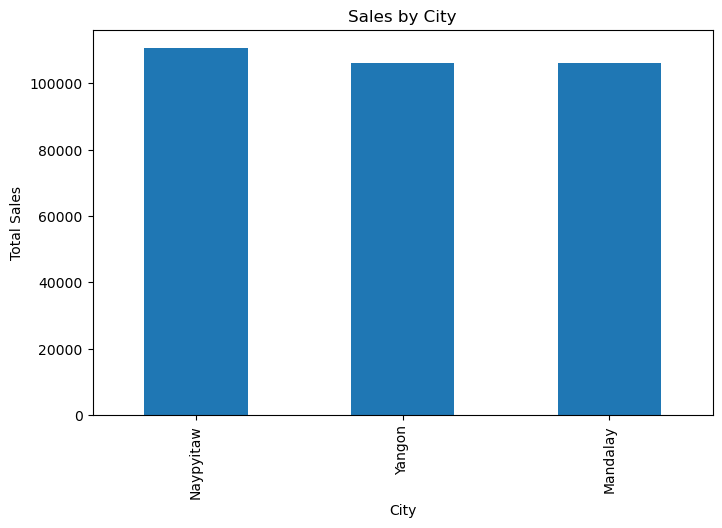

In [25]:
city_sales.plot(kind="bar", figsize=(8,5))
plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()

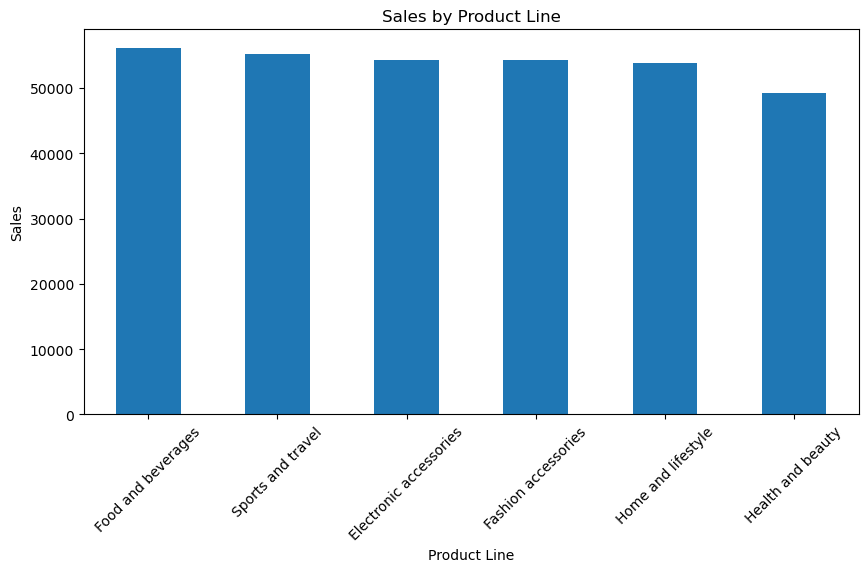

In [26]:
product_sales.plot(kind="bar", figsize=(10,5))
plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

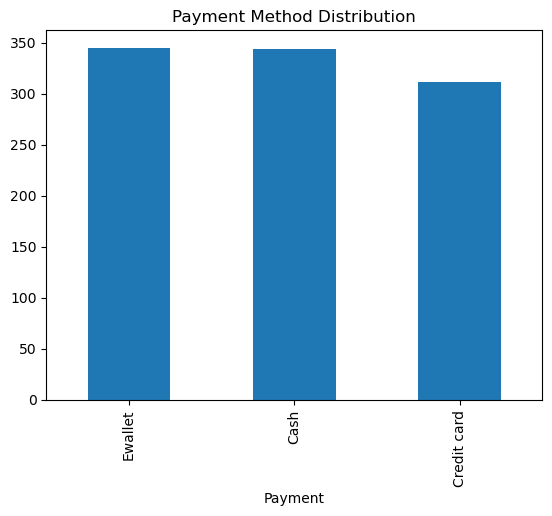

In [27]:
payment_method.plot(kind="bar")
plt.title("Payment Method Distribution")
plt.show()

In [29]:
df.to_csv("cleaned_supermarket_sales.csv", index=False)

In [30]:
branch_sales = df.groupby("Branch")["Sales"].sum().sort_values(ascending=False)
print(branch_sales)

Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64


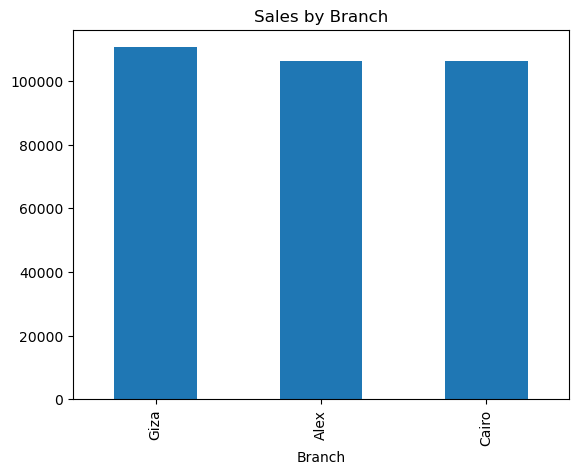

In [31]:
branch_sales.plot(kind='bar')
plt.title("Sales by Branch")
plt.show()

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


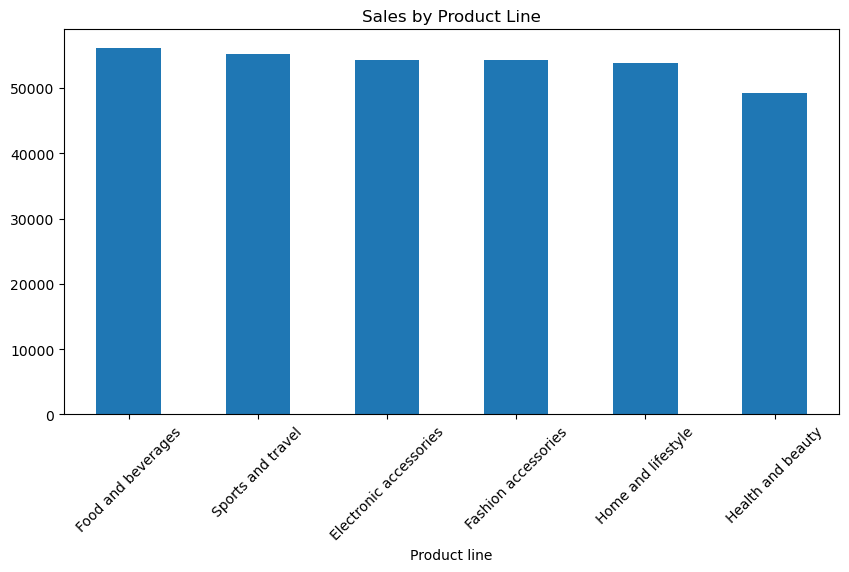

In [32]:
product_sales = df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)
print(product_sales)
product_sales.plot(kind='bar', figsize=(10,5))
plt.title("Sales by Product Line")
plt.xticks(rotation=45)
plt.show()

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64


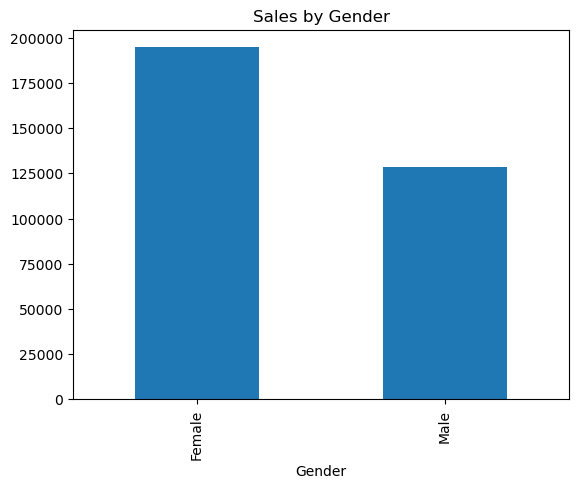

In [33]:
gender_sales = df.groupby("Gender")["Sales"].sum()
print(gender_sales)
gender_sales.plot(kind='bar')
plt.title("Sales by Gender")
plt.show()

Hour
2026-07-10 10:00:00    979.9230
2026-07-10 10:01:00    205.9470
2026-07-10 10:02:00    784.6125
2026-07-10 10:03:00    335.0130
2026-07-10 10:04:00    827.0850
                         ...   
2026-07-10 20:52:00    352.5795
2026-07-10 20:54:00    375.6060
2026-07-10 20:55:00    783.3000
2026-07-10 20:57:00    148.9950
2026-07-10 20:59:00    408.1455
Name: Sales, Length: 506, dtype: float64


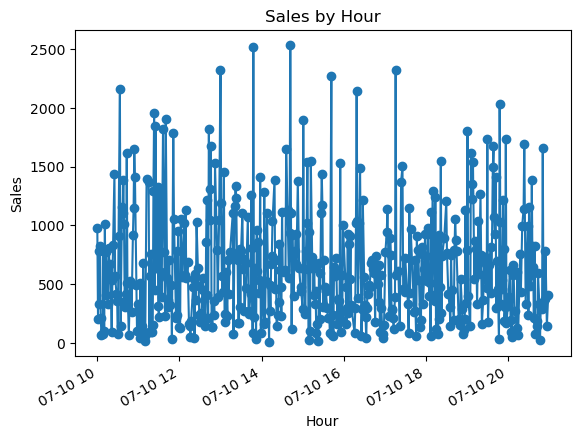

In [34]:
hour_sales = df.groupby("Hour")["Sales"].sum()
print(hour_sales)
hour_sales.plot(kind='line', marker='o')
plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Sales")
plt.show()

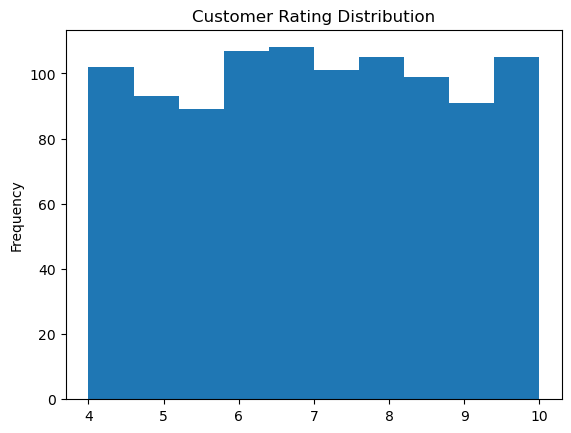

In [35]:
df["Rating"].plot(kind='hist', bins=10)
plt.title("Customer Rating Distribution")
plt.show()


In [36]:
correlation = df.corr(numeric_only=True)
print(correlation)

                         Unit price  Quantity    Tax 5%     Sales      cogs  \
Unit price                 1.000000  0.010778  0.633962  0.633962  0.633962   
Quantity                   0.010778  1.000000  0.705510  0.705510  0.705510   
Tax 5%                     0.633962  0.705510  1.000000  1.000000  1.000000   
Sales                      0.633962  0.705510  1.000000  1.000000  1.000000   
cogs                       0.633962  0.705510  1.000000  1.000000  1.000000   
gross margin percentage         NaN       NaN       NaN       NaN       NaN   
gross income               0.633962  0.705510  1.000000  1.000000  1.000000   
Rating                    -0.008778 -0.015815 -0.036442 -0.036442 -0.036442   

                         gross margin percentage  gross income    Rating  
Unit price                                   NaN      0.633962 -0.008778  
Quantity                                     NaN      0.705510 -0.015815  
Tax 5%                                       NaN      1.000000 

# Business Insights

1. Highest Sales City:
2. Best Performing Branch:
3. Highest Revenue Product Line:
4. Most Preferred Payment Method:
5. Female customers generated higher sales.
6. Peak Sales Hour:
7. Average Customer Rating: